In [22]:
using Plots,JLD2,LinearAlgebra

In [23]:
Nx=28
Ny=28
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.01
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [24]:
st=load("test.jld2")
   

Dict{String, Any} with 12 entries:
  "Eelec"          => -2.38826
  "spectrum"       => [-4.74107, -4.74086, -4.72262, -4.72241, -4.7224, -4.7222…
  "max_record"     => 0.108829
  "average_record" => 0.056709
  "orbital_id"     => [1 29 … 729 757; 2 30 … 730 758; … ; 27 55 … 755 783; 28 …
  "phonon_id"      => [1 29 … 729 757; 2 30 … 730 758; … ; 27 55 … 755 783; 28 …
  "phonon_coor"    => [-0.00999708, 0.0448311, -0.0678566, 0.056274, -0.0219554…
  "FL"             => 1.57451
  "ave_npa"        => 980.0
  "E_total"        => -2.38081
  "Egap"           => 0.0890435
  "free_energy"    => -2.38082

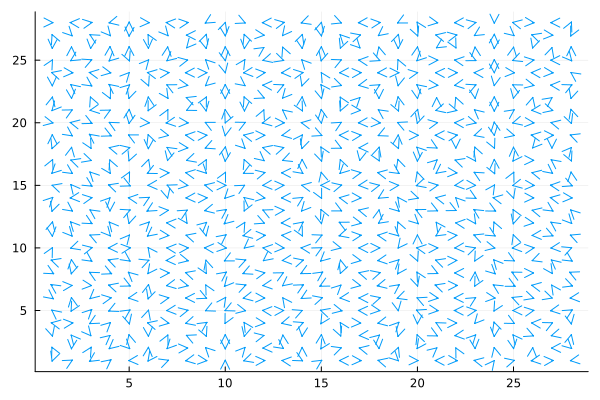

In [25]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(vec(dis_x),vec(dis_y)))




In [26]:
#savefig(p1,"quiverplot.png")

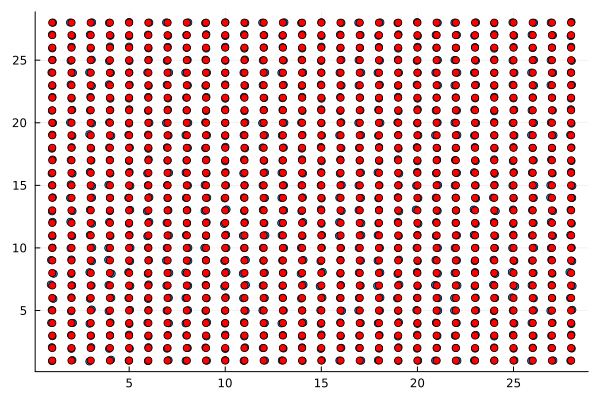

In [27]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [28]:
#savefig(p2,"atomplot.png")

In [29]:
sort(vec(dis_y)-vec(atom_y))

784-element Vector{Float64}:
 -0.08148136954890006
 -0.07951029077714011
 -0.0791629270202927
 -0.07900465506888965
 -0.0775860985407757
 -0.07704074916335557
 -0.07663656951277531
 -0.07636254997697112
 -0.0762245105026107
 -0.07619007290692892
  ⋮
  0.0780926513632072
  0.07844142076037386
  0.07888393190984111
  0.08009729806369137
  0.08209915371297072
  0.08526567462925883
  0.08686423906775254
  0.09082167783628847
  0.09275479724465185

In [30]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

784-element Vector{Float64}:
  1.3759699146329625
  2.287108732563473
  2.2934560880742576
  2.781984033694166
  3.076550847434679
  3.1161044580133206
  3.623344203512903
  3.665664185593229
  4.125598430976779
  4.194540396584914
  ⋮
 37.49035029602855
 37.51524476893538
 37.52359957058868
 38.21345130243535
 38.25038742607312
 38.260113937495035
 38.83033269882943
 38.855247182905345
 39.64542156054117

In [31]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

22.07344624551859

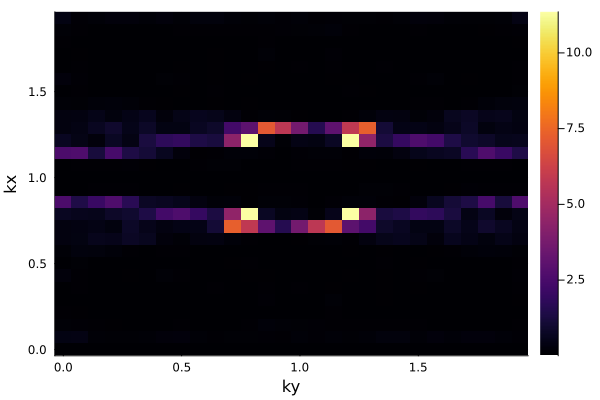

In [32]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [33]:
sort(vec(abs.(Fourier_mode_x)))

784-element Vector{Float64}:
  3.625572064791527e-16
  1.349617409374533e-15
  1.5021147322918932e-15
  1.6142534540416948e-15
  2.4076236869633328e-15
  2.578061219418169e-15
  4.403453679506072e-15
  4.546097306062785e-15
  5.936631167159073e-15
  5.968081516294813e-15
  ⋮
  5.799571940793617
  7.076839245306665
  7.076839245306667
  7.270026059354845
  7.270026059354864
 11.33572531340743
 11.335725313407439
 11.357404551845034
 11.35740455184505

In [34]:
findmax(abs.(Fourier_mode_x))

(11.35740455184505, CartesianIndex(12, 18))

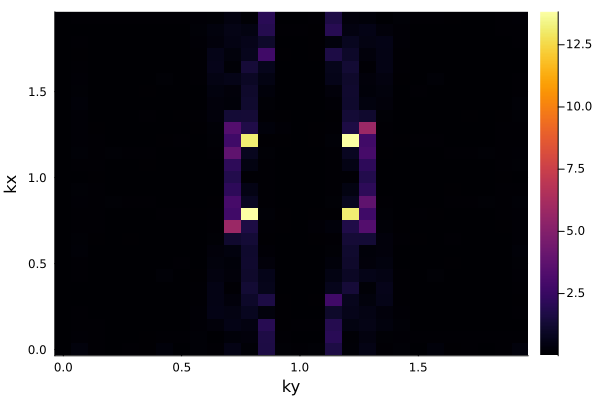

In [35]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [36]:
findmax(abs.(Fourier_mode_y))

(13.824758363537065, CartesianIndex(18, 18))

In [37]:
Fourier_mode_y[8,14]

-0.0014340368150650845 + 0.011958139113081676im

In [38]:
Fourier_mode_x[8,14]

0.002900826800553511 - 0.0029290467450216497im

In [39]:
Fourier_mode_y[14,8]

-0.0014403437873226274 - 0.0024811690821261966im

In [40]:
Fourier_mode_x[14,8]

0.02966171690741582 + 0.005409336374215613im

In [41]:
Fourier_mode_y[8,8]

-0.022654857455385674 - 0.045022671437193434im

In [42]:
Fourier_mode_x[8,8]

0.008726204292993325 + 0.02404143519354088im